<a href="https://colab.research.google.com/github/LaibaSaleem01/random-forest-parameter-testing/blob/main/Random_Forest_Complete_Explained_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest From Scratch: Complete Explained Notebook

This notebook uses the **Iris flower dataset** to teach Random Forest step by step.

You will learn how a Random Forest works, how to code it, how to test its parameters, how to evaluate it, and how to visualize one of its Decision Trees.

## What is a Random Forest?

A Decision Tree predicts by asking questions such as:

```text
Is petal length <= 2.45?
```

A Random Forest creates many different Decision Trees. Every tree trains on a random sample of rows and considers random features when making splits. The trees then combine their predictions.

```text
Tree 1: Versicolor
Tree 2: Virginica
Tree 3: Versicolor
Tree 4: Versicolor

Final Random Forest prediction: Versicolor
```


## Cell 1: Import libraries

We import tools for loading data, training the model, evaluating it, testing parameters, and drawing graphs.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.tree import plot_tree

pd.set_option("display.max_columns", None)
print("Libraries imported successfully.")

Libraries imported successfully.


### Why these imports?

- `pandas` displays data in rows and columns.
- `numpy` helps with numerical values.
- `matplotlib` creates graphs.
- `RandomForestClassifier` is the model.
- `train_test_split` separates training and testing data.
- `cross_val_score` and `StratifiedKFold` help compare parameters fairly.
- `GridSearchCV` tests parameter combinations.
- `plot_tree` draws one tree from the forest.


## Cell 2: Load the Iris dataset

`X` contains the flower measurements. `y` contains the correct flower class.

In [2]:
iris = load_iris(as_frame=True)

X = iris.data
y = iris.target

print("Input shape:", X.shape)
print("Target shape:", y.shape)
print("Flower classes:", iris.target_names)

Input shape: (150, 4)
Target shape: (150,)
Flower classes: ['setosa' 'versicolor' 'virginica']


In machine learning:

```text
X = input information
y = correct answer
```

The target labels mean:

```text
0 = Setosa
1 = Versicolor
2 = Virginica
```


## Cell 3: View the input features

In [3]:
display(X.head(10))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


Each row is one flower. The four columns are the measurements the model will use.

## Cell 4: Create a readable complete table

This table is only for understanding the data. The model still trains using `X` and `y`.

In [4]:
df = X.copy()
df["target"] = y
df["flower_name"] = df["target"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

display(df.head(10))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,flower_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
5,5.4,3.9,1.7,0.4,0,setosa
6,4.6,3.4,1.4,0.3,0,setosa
7,5.0,3.4,1.5,0.2,0,setosa
8,4.4,2.9,1.4,0.2,0,setosa
9,4.9,3.1,1.5,0.1,0,setosa


## Cell 5: Inspect the dataset

Before training, we check the size, missing values, statistics, and class balance.

In [5]:
print("Dataset shape:", df.shape)

print("\nMissing values:")
display(df.isnull().sum())

print("\nStatistical summary:")
display(df.describe())

print("\nClass counts:")
display(df["flower_name"].value_counts())

Dataset shape: (150, 6)

Missing values:


,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
target,0
flower_name,0



Statistical summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Class counts:


,count
flower_name,
setosa,50
versicolor,50
virginica,50


The Iris dataset is clean and balanced, which makes it useful for learning.

## Cell 6: Split the data

The model learns from the training set. The test set is kept separate for the final evaluation.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training examples:", X_train.shape[0])
print("Testing examples:", X_test.shape[0])
print("\nTraining class counts:")
print(y_train.value_counts().sort_index())
print("\nTesting class counts:")
print(y_test.value_counts().sort_index())

Training examples: 120
Testing examples: 30

Training class counts:
target
0    40
1    40
2    40
Name: count, dtype: int64

Testing class counts:
target
0    10
1    10
2    10
Name: count, dtype: int64


### Meaning of the split settings

- `test_size=0.20`: 80% training and 20% testing.
- `random_state=42`: gives the same random split each time.
- `stratify=y`: keeps the three classes balanced in both sets.


## Cell 7: Create the Random Forest

This creates the model settings. It does not train the model yet.

In [7]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

print(random_forest)

RandomForestClassifier(n_jobs=-1, random_state=42)


### Important parameters

- `n_estimators=100`: create 100 Decision Trees.
- `criterion="gini"`: judge how pure or mixed a split is.
- `max_depth=None`: no fixed depth limit.
- `min_samples_split=2`: at least two examples are needed to split a node.
- `min_samples_leaf=1`: a final leaf may contain one example.
- `max_features="sqrt"`: consider a random subset of features at each split.
- `bootstrap=True`: every tree receives a random sample of rows with replacement.
- `random_state=42`: makes the randomness repeatable.
- `n_jobs=-1`: use all available processor cores.


## Cell 8: Train the Random Forest

`.fit()` is where learning happens.

In [8]:
random_forest.fit(X_train, y_train)

print("Model trained successfully.")
print("Number of trained trees:", len(random_forest.estimators_))

Model trained successfully.
Number of trained trees: 100


### What happens inside `.fit()`?

For every tree:

1. A random bootstrap sample of training rows is created.
2. The tree begins at a root node.
3. A random subset of features is considered.
4. Different questions and thresholds are tested.
5. The split producing purer groups is selected.
6. The process continues until a stopping rule is reached.
7. The completed tree is stored in `random_forest.estimators_`.


## Cell 9: Make predictions

Every test flower passes through all the trees. The forest combines their class probabilities.

In [9]:
predictions = random_forest.predict(X_test)

print("Predictions:")
print(predictions)

print("\nCorrect answers:")
print(y_test.to_numpy())

Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 2 1 0 2 0]

Correct answers:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


## Cell 10: View prediction probabilities

In [10]:
probabilities = random_forest.predict_proba(X_test)

probability_df = pd.DataFrame(
    probabilities,
    columns=iris.target_names
)
probability_df["predicted_class"] = [
    iris.target_names[p] for p in predictions
]

display(probability_df.head(10))

,setosa,versicolor,virginica,predicted_class
0,1.00,0.00,0.00,setosa
1,0.00,0.14,0.86,virginica
2,0.00,0.81,0.19,versicolor
3,0.00,0.93,0.07,versicolor
4,1.00,0.00,0.00,setosa
5,0.00,0.91,0.09,versicolor
6,1.00,0.00,0.00,setosa
7,1.00,0.00,0.00,setosa
8,0.00,0.00,1.00,virginica
9,0.01,0.90,0.09,versicolor


The final class is the class with the highest combined probability.

## Cell 11: Calculate accuracy

In [11]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Accuracy percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9
Accuracy percentage: 90.0 %


Accuracy means:

```text
Correct predictions / Total predictions
```


## Cell 12: Precision, recall, and F1 score

In [12]:
print(
    classification_report(
        y_test,
        predictions,
        target_names=iris.target_names
    )
)

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



- **Precision:** Of everything predicted as a class, how much was correct?
- **Recall:** Of everything actually belonging to a class, how much was found?
- **F1 score:** A balance between precision and recall.
- **Support:** Number of actual examples in the class.


## Cell 13: Confusion matrix

Rows are actual classes. Columns are predicted classes. Correct predictions appear on the diagonal.

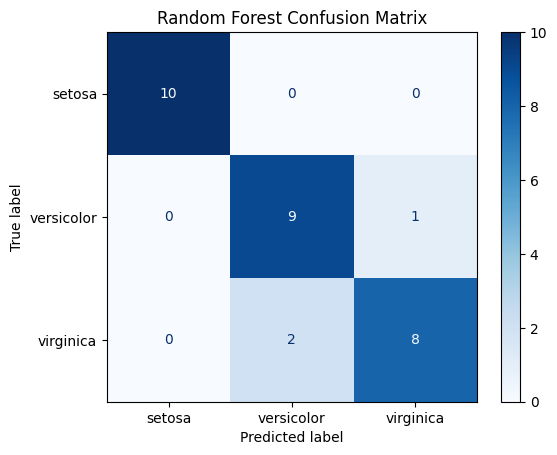

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    display_labels=iris.target_names,
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.show()

## Cell 14: Visualize one tree

A Random Forest has many trees, so we normally display only one of them.

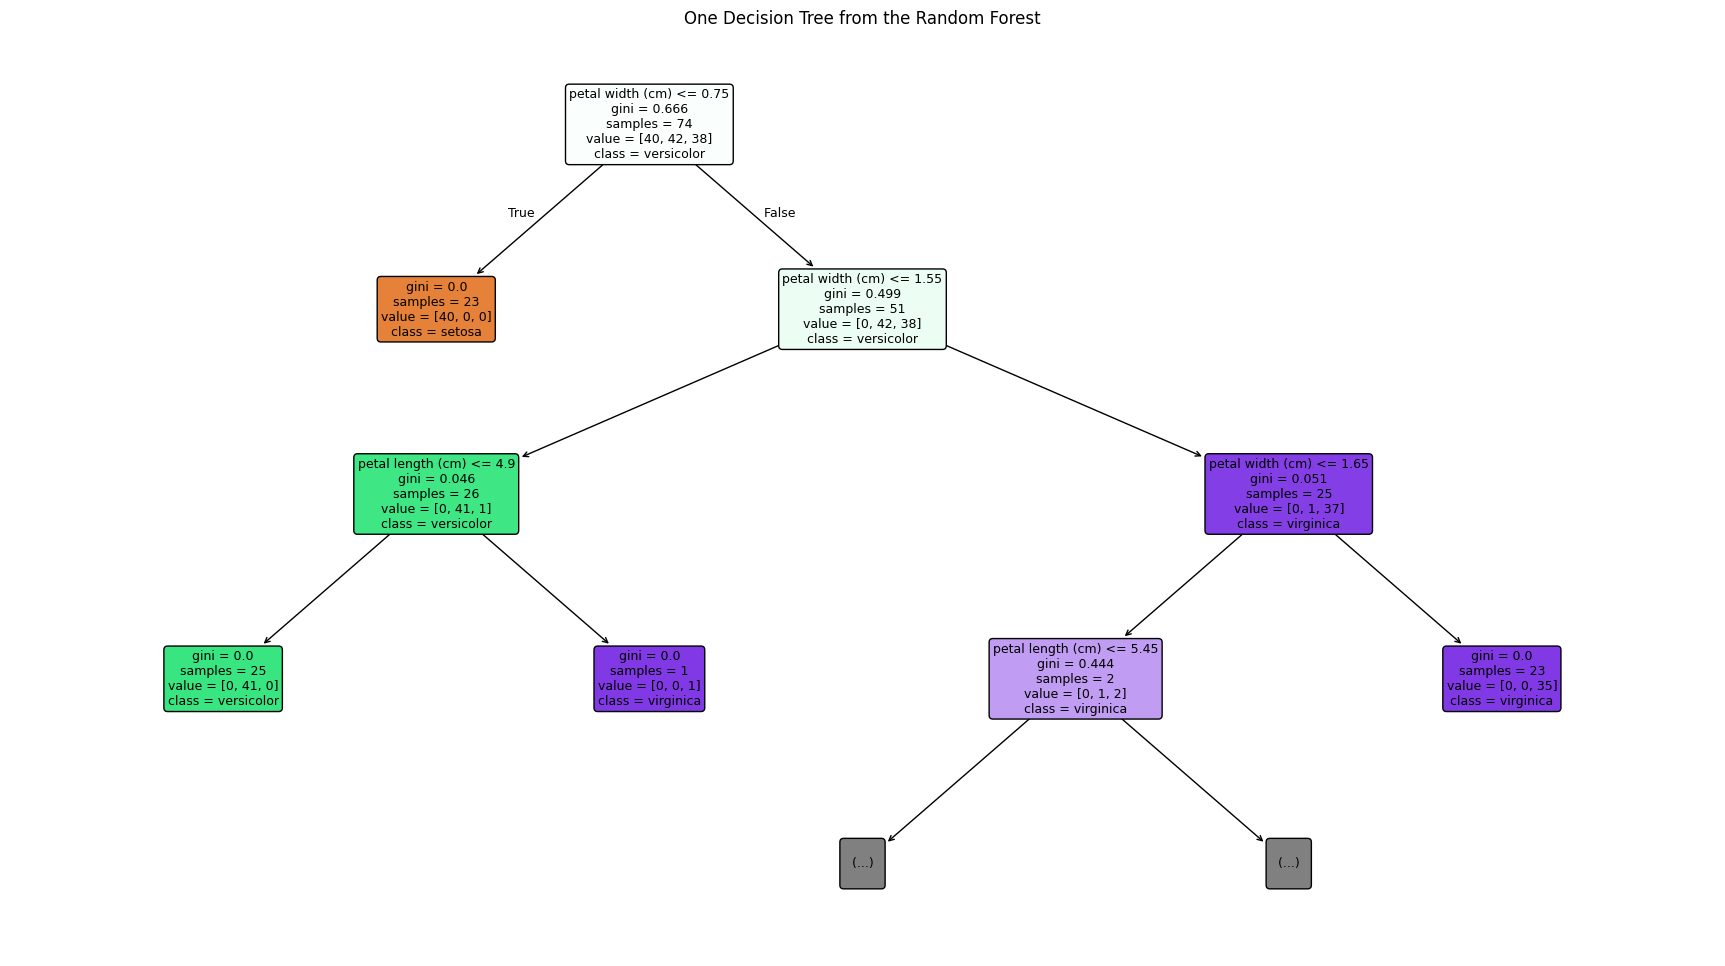

In [14]:
one_tree = random_forest.estimators_[0]

plt.figure(figsize=(22, 12))
plot_tree(
    one_tree,
    feature_names=X.columns,
    class_names=list(iris.target_names),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("One Decision Tree from the Random Forest")
plt.show()

### How to read a node

A node may contain:

```text
petal length (cm) <= 2.45
gini = 0.666
samples = 76
value = [39, 37, 44]
class = virginica
```

- The first line is the question.
- `gini` shows how mixed the classes are.
- `samples` shows how many bootstrap observations reached the node.
- `value` shows the class distribution in the order Setosa, Versicolor, Virginica.
- `class` is the class the node would predict.

The `max_depth=3` inside `plot_tree()` only limits the displayed diagram. It does not change the trained model.


## Cell 15: Feature importance

Feature importance shows which measurements contributed most across the forest.

,importance
petal width (cm),0.437185
petal length (cm),0.431466
sepal length (cm),0.116349
sepal width (cm),0.015000


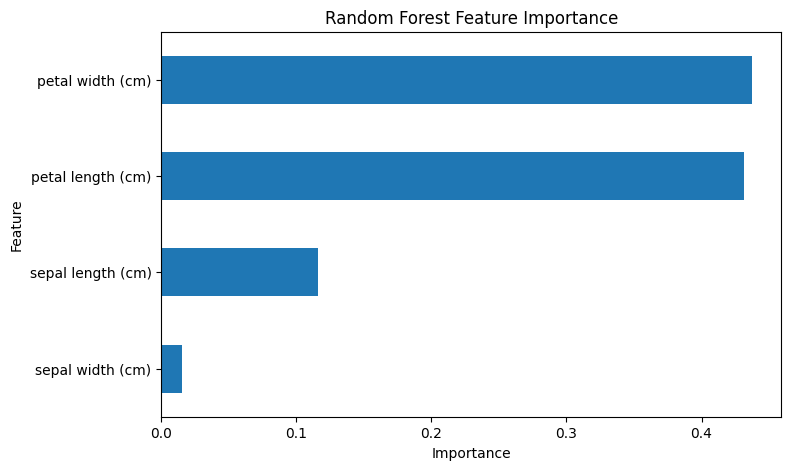

Total importance: 1.0


In [15]:
feature_importance = pd.Series(
    random_forest.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(feature_importance.to_frame("importance"))

plt.figure(figsize=(8, 5))
feature_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.show()

print("Total importance:", random_forest.feature_importances_.sum())

The importance values add up to approximately 1. A larger value means the feature was used more effectively for splitting.

## Cell 16: Create five-fold cross-validation

We use only the training data to compare parameters. This protects the final test set.

In [16]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(cv)

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


The training data is divided into five folds. The model trains five times, each time using a different fold for validation. `StratifiedKFold` keeps classes balanced.

## Cell 17: Create a reusable parameter-testing function

The function tests one parameter at several values, performs cross-validation, stores the mean accuracy and standard deviation, and draws a graph.

In [17]:
def test_parameter(parameter_name, values):
    results = []

    for value in values:
        model_parameters = {
            "n_estimators": 100,
            "random_state": 42,
            "n_jobs": -1
        }

        # Change only the parameter being tested
        model_parameters[parameter_name] = value

        temporary_model = RandomForestClassifier(
            **model_parameters
        )

        scores = cross_val_score(
            temporary_model,
            X_train,
            y_train,
            cv=cv,
            scoring="accuracy"
        )

        results.append({
            "parameter": parameter_name,
            "value": str(value),
            "mean_accuracy": scores.mean(),
            "standard_deviation": scores.std()
        })

    results_df = pd.DataFrame(results)
    display(results_df)

    positions = np.arange(len(results_df))

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        positions,
        results_df["mean_accuracy"],
        yerr=results_df["standard_deviation"],
        marker="o",
        capsize=5
    )
    plt.xticks(positions, results_df["value"])
    plt.xlabel(parameter_name)
    plt.ylabel("Mean cross-validation accuracy")
    plt.title(f"Effect of {parameter_name} on accuracy")
    plt.ylim(0.70, 1.01)
    plt.grid(alpha=0.3)
    plt.show()

    best_row = results_df.loc[
        results_df["mean_accuracy"].idxmax()
    ]

    print("Best tested value:", best_row["value"])
    print(
        "Best mean CV accuracy:",
        round(best_row["mean_accuracy"], 4)
    )

    return results_df

### What happens inside the function?

- `for value in values` tests one value at a time.
- `model_parameters[parameter_name] = value` changes only the selected parameter.
- `**model_parameters` sends the dictionary settings into the model.
- `cross_val_score` trains and validates the model five times.
- `scores.mean()` gives average accuracy.
- `scores.std()` measures how much the five scores differ.


## Cell 18: Test the number of trees

,parameter,value,mean_accuracy,standard_deviation
0,n_estimators,1,0.966667,0.040825
1,n_estimators,5,0.941667,0.020412
2,n_estimators,10,0.941667,0.020412
3,n_estimators,25,0.941667,0.020412
4,n_estimators,50,0.958333,0.026352
5,n_estimators,100,0.950000,0.031180
6,n_estimators,200,0.950000,0.031180


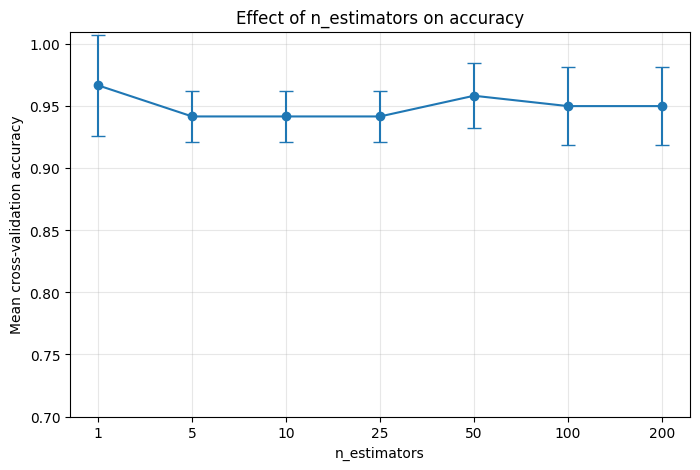

Best tested value: 1
Best mean CV accuracy: 0.9667


In [18]:
n_estimators_results = test_parameter(
    "n_estimators",
    [1, 5, 10, 25, 50, 100, 200]
)

More trees usually make the forest more stable, but after a point they may add computation without much improvement.

## Cell 19: Test maximum depth

,parameter,value,mean_accuracy,standard_deviation
0,max_depth,1,0.966667,0.031180
1,max_depth,2,0.950000,0.016667
2,max_depth,3,0.958333,0.026352
3,max_depth,4,0.950000,0.031180
4,max_depth,5,0.950000,0.031180
5,max_depth,None,0.950000,0.031180


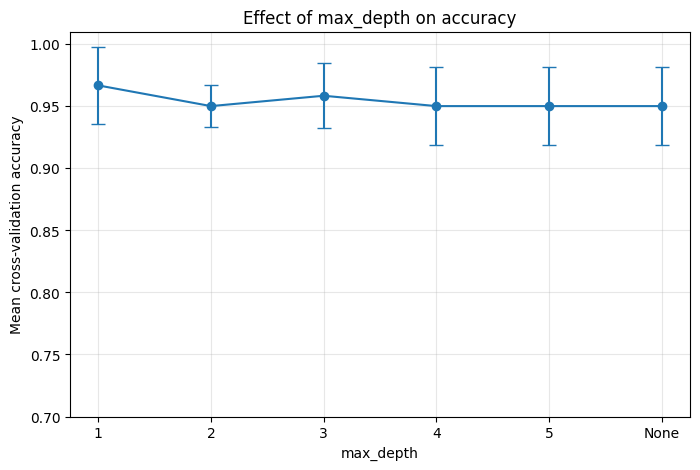

Best tested value: 1
Best mean CV accuracy: 0.9667


In [19]:
max_depth_results = test_parameter(
    "max_depth",
    [1, 2, 3, 4, 5, None]
)

A very small depth can underfit. A very large depth creates more complex trees. `None` means no fixed depth limit.

## Cell 20: Test minimum samples needed to split

,parameter,value,mean_accuracy,standard_deviation
0,min_samples_split,2,0.950000,0.031180
1,min_samples_split,5,0.958333,0.026352
2,min_samples_split,10,0.958333,0.026352
3,min_samples_split,15,0.958333,0.026352
4,min_samples_split,20,0.966667,0.031180


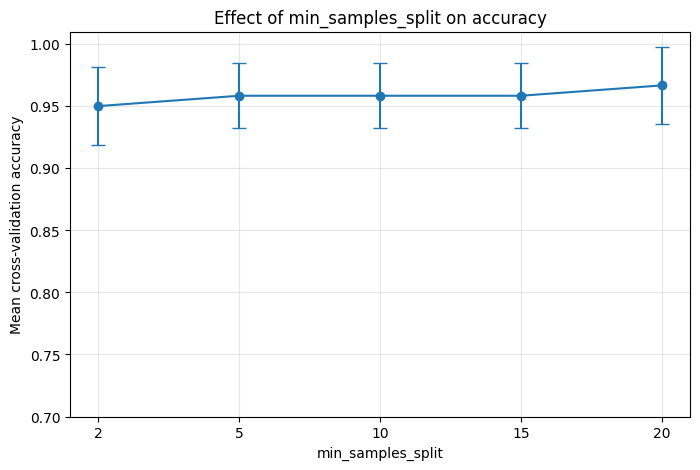

Best tested value: 20
Best mean CV accuracy: 0.9667


In [20]:
min_samples_split_results = test_parameter(
    "min_samples_split",
    [2, 5, 10, 15, 20]
)

A small value allows detailed trees. A large value makes the trees simpler.

## Cell 21: Test minimum samples in a leaf

,parameter,value,mean_accuracy,standard_deviation
0,min_samples_leaf,1,0.950000,0.031180
1,min_samples_leaf,2,0.966667,0.031180
2,min_samples_leaf,4,0.958333,0.026352
3,min_samples_leaf,6,0.958333,0.026352
4,min_samples_leaf,8,0.958333,0.026352
5,min_samples_leaf,10,0.950000,0.016667


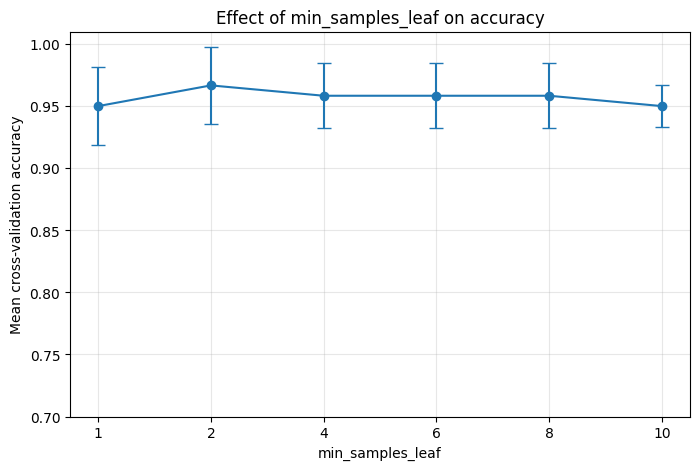

Best tested value: 2
Best mean CV accuracy: 0.9667


In [21]:
min_samples_leaf_results = test_parameter(
    "min_samples_leaf",
    [1, 2, 4, 6, 8, 10]
)

A larger leaf size prevents the model from creating leaves from only one or two unusual observations.

## Cell 22: Test maximum features

,parameter,value,mean_accuracy,standard_deviation
0,max_features,sqrt,0.950000,0.031180
1,max_features,log2,0.950000,0.031180
2,max_features,None,0.941667,0.020412


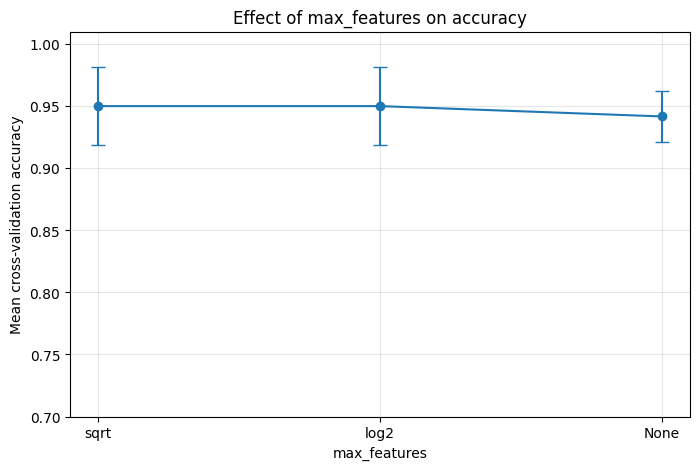

Best tested value: sqrt
Best mean CV accuracy: 0.95


In [22]:
max_features_results = test_parameter(
    "max_features",
    ["sqrt", "log2", None]
)

- `sqrt` considers the square root of all features.
- `log2` considers the base-two logarithm of all features.
- `None` considers all features.

Random feature selection helps make the trees different from one another.


## Cell 23: Test splitting criteria

,parameter,value,mean_accuracy,standard_deviation
0,criterion,gini,0.95,0.03118
1,criterion,entropy,0.95,0.03118
2,criterion,log_loss,0.95,0.03118


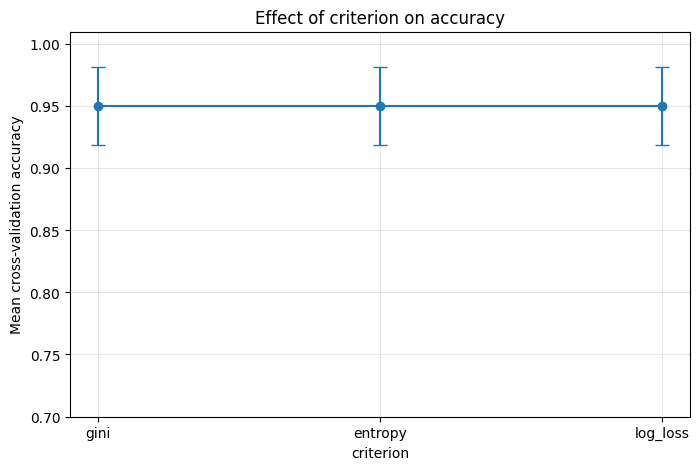

Best tested value: gini
Best mean CV accuracy: 0.95


In [23]:
criterion_results = test_parameter(
    "criterion",
    ["gini", "entropy", "log_loss"]
)

These are different mathematical ways of judging how useful a split is.

## Cell 24: Use GridSearchCV

Testing one parameter at a time is useful for learning, but parameters can affect each other. Grid Search tests combinations.

In [24]:
parameter_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", None]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_grid=parameter_grid,
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(grid_search.best_score_)

Best parameters:
{'max_depth': 2, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation accuracy:
0.9666666666666668


The grid contains 144 parameter combinations. With five-fold cross-validation, this produces 720 training operations.

## Cell 25: View the best Grid Search results

In [25]:
grid_results = pd.DataFrame(grid_search.cv_results_)

columns_to_show = [
    "param_n_estimators",
    "param_max_depth",
    "param_min_samples_split",
    "param_min_samples_leaf",
    "param_max_features",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score"
]

top_results = (
    grid_results[columns_to_show]
    .sort_values("rank_test_score")
    .head(10)
)

display(top_results)

,param_n_estimators,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_features,mean_train_score,mean_test_score,std_test_score,rank_test_score
2,200,2,2,1,sqrt,0.970833,0.966667,0.03118,1
5,200,2,5,1,sqrt,0.970833,0.966667,0.03118,1
11,200,2,5,2,sqrt,0.970833,0.966667,0.03118,1
8,200,2,2,2,sqrt,0.970833,0.966667,0.03118,1
14,200,2,2,4,sqrt,0.970833,0.966667,0.03118,1
17,200,2,5,4,sqrt,0.970833,0.966667,0.03118,1
46,100,3,5,2,sqrt,0.983333,0.966667,0.03118,1
44,200,3,2,2,sqrt,0.981250,0.966667,0.03118,1
43,100,3,2,2,sqrt,0.983333,0.966667,0.03118,1
47,200,3,5,2,sqrt,0.981250,0.966667,0.03118,1


`rank_test_score=1` is the best tested combination. Here, `test` means the validation folds inside cross-validation, not the final test set.

## Cell 26: Get the best model

In [26]:
best_model = grid_search.best_estimator_
print(best_model)

RandomForestClassifier(max_depth=2, n_estimators=200, n_jobs=-1,
                       random_state=42)


## Cell 27: Final evaluation on the untouched test set

In [27]:
final_predictions = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)

print("Final test accuracy:", final_accuracy)
print("Final percentage:", round(final_accuracy * 100, 2), "%")

print("\nFinal classification report:")
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=iris.target_names
    )
)

Final test accuracy: 0.9333333333333333
Final percentage: 93.33 %

Final classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## Cell 28: Compare training and testing accuracy

A very large gap may suggest overfitting.

In [28]:
training_predictions = best_model.predict(X_train)
training_accuracy = accuracy_score(y_train, training_predictions)
testing_accuracy = accuracy_score(y_test, final_predictions)

print("Training accuracy:", training_accuracy)
print("Testing accuracy:", testing_accuracy)
print("Difference:", training_accuracy - testing_accuracy)

Training accuracy: 0.9666666666666667
Testing accuracy: 0.9333333333333333
Difference: 0.033333333333333326


For example, training accuracy of 1.00 and testing accuracy of 0.70 would be concerning. A much smaller difference gives less evidence of serious overfitting.

## Cell 29: Final confusion matrix

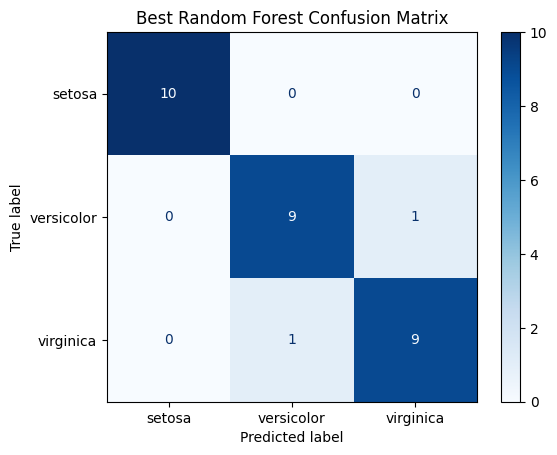

In [29]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=iris.target_names,
    cmap="Blues"
)
plt.title("Best Random Forest Confusion Matrix")
plt.show()

## Cell 30: Feature importance from the best model

,importance
petal length (cm),0.450103
petal width (cm),0.409167
sepal length (cm),0.136869
sepal width (cm),0.003861


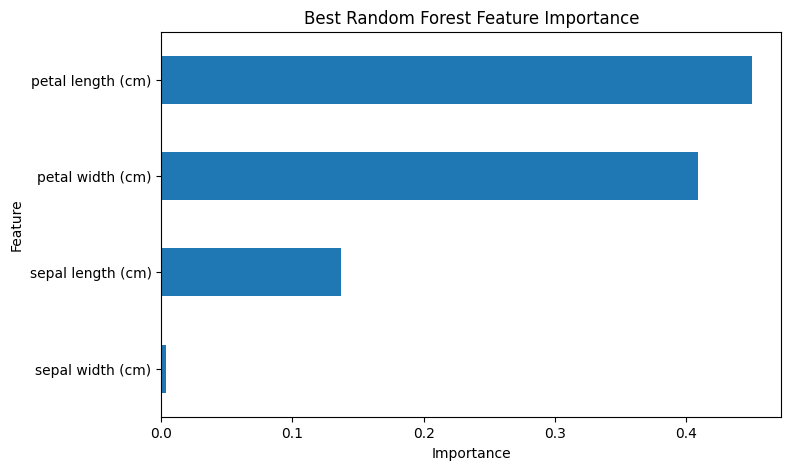

In [30]:
best_feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(best_feature_importance.to_frame("importance"))

plt.figure(figsize=(8, 5))
best_feature_importance.sort_values().plot(kind="barh")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Best Random Forest Feature Importance")
plt.show()

## Cell 31: Visualize one tree from the best forest

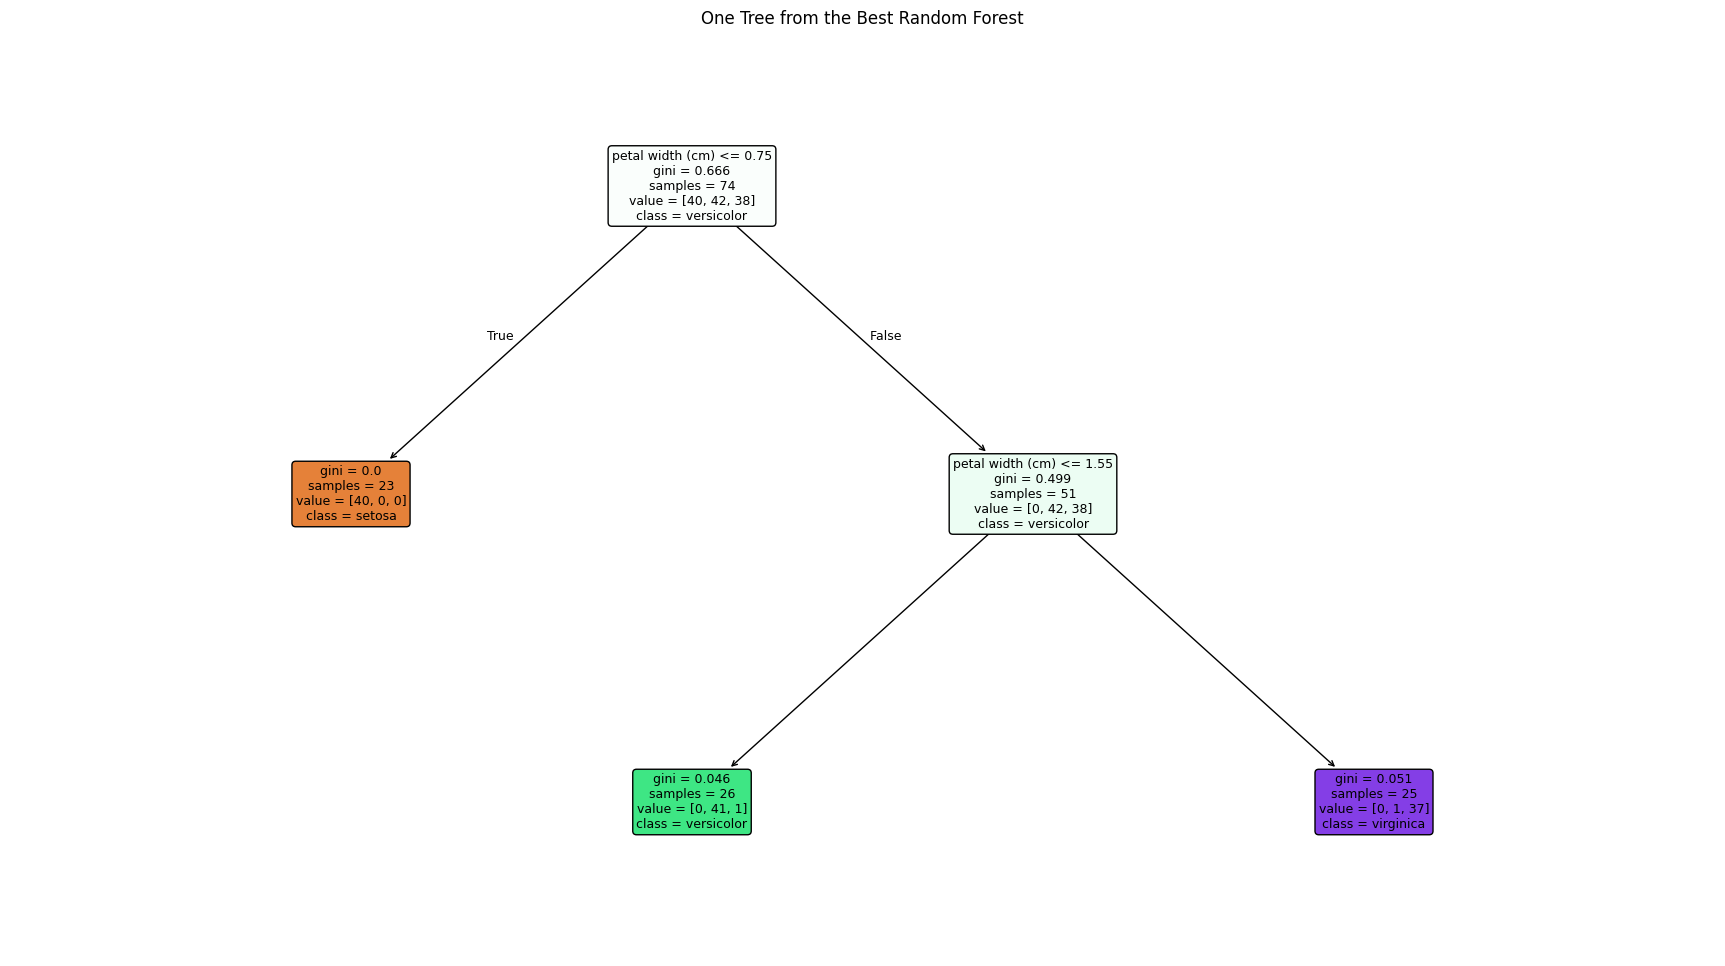

In [31]:
best_tree = best_model.estimators_[0]

plt.figure(figsize=(22, 12))
plot_tree(
    best_tree,
    feature_names=X.columns,
    class_names=list(iris.target_names),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title("One Tree from the Best Random Forest")
plt.show()

This is one individual tree. The full Random Forest prediction combines every tree in the best model.

## Cell 32: Compare shallow and deeper trees visually

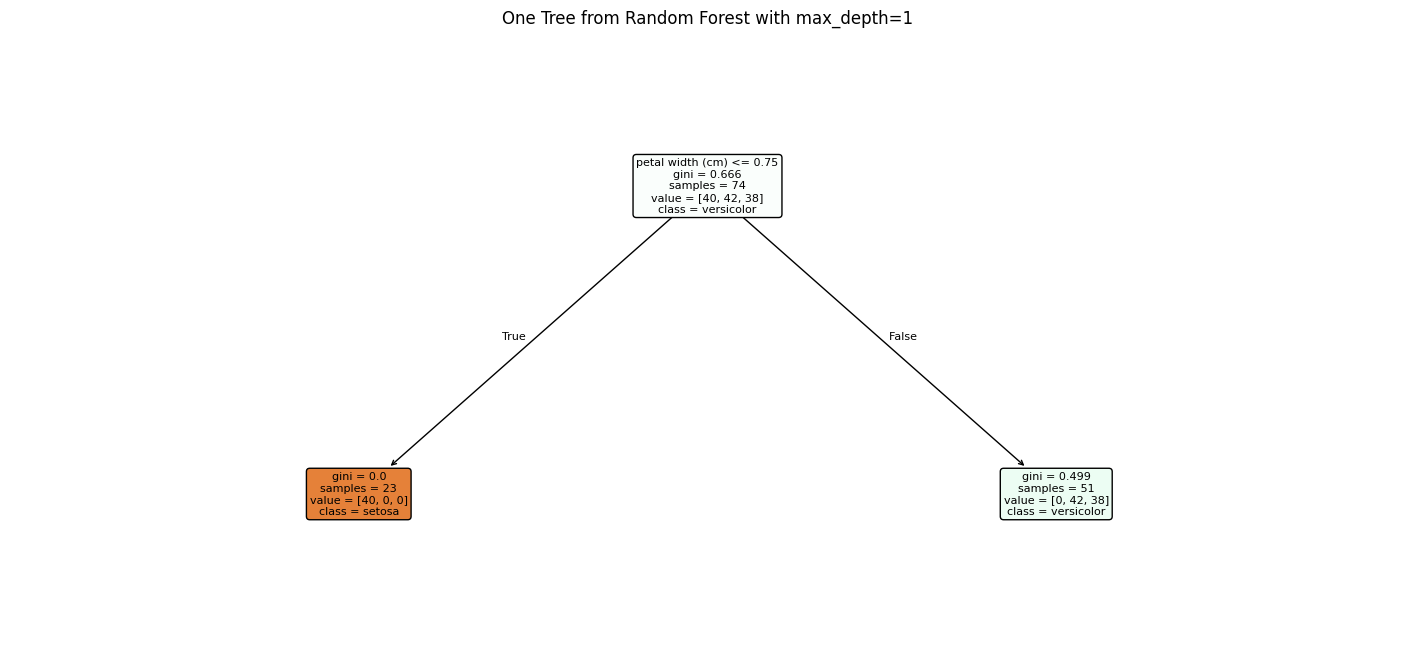

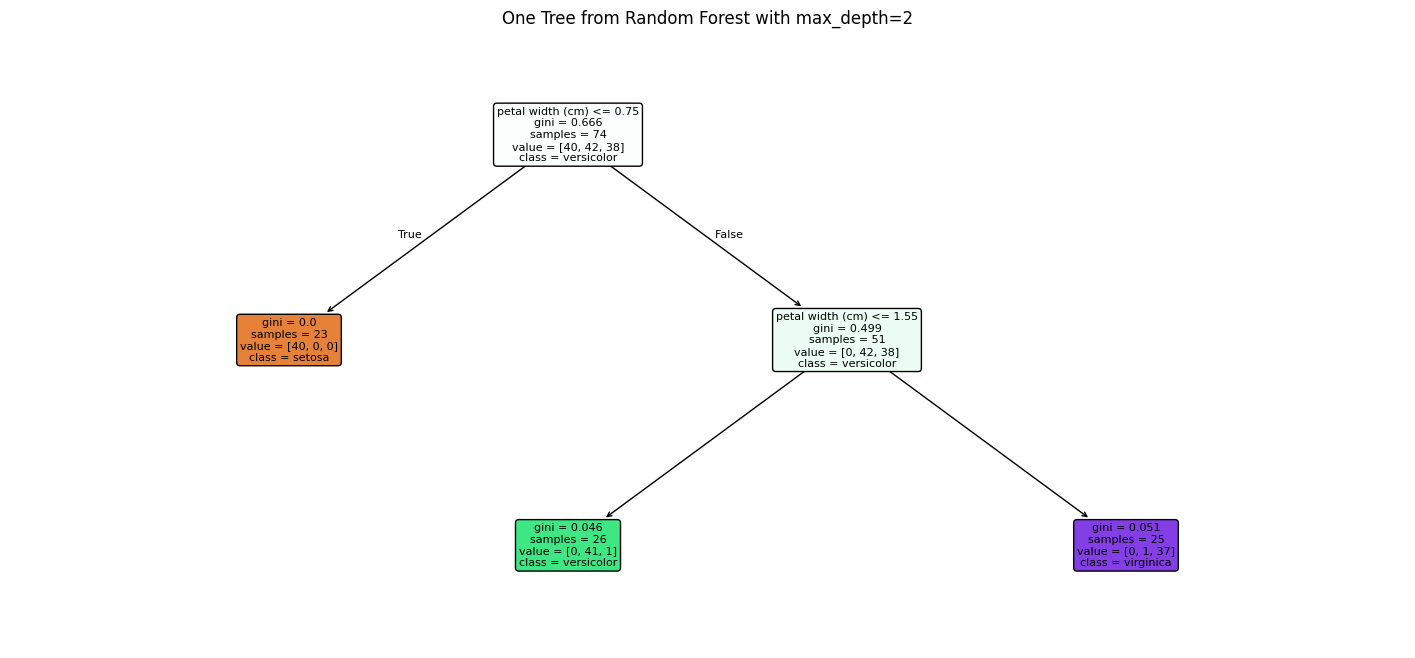

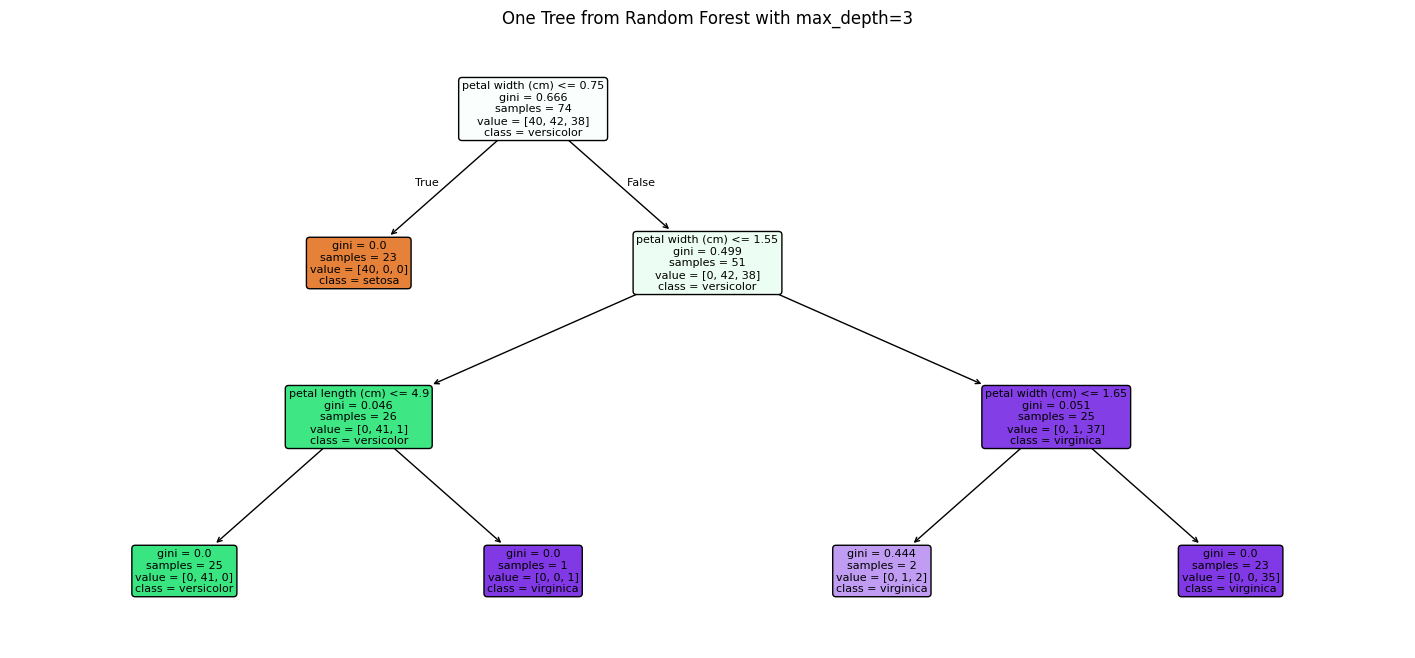

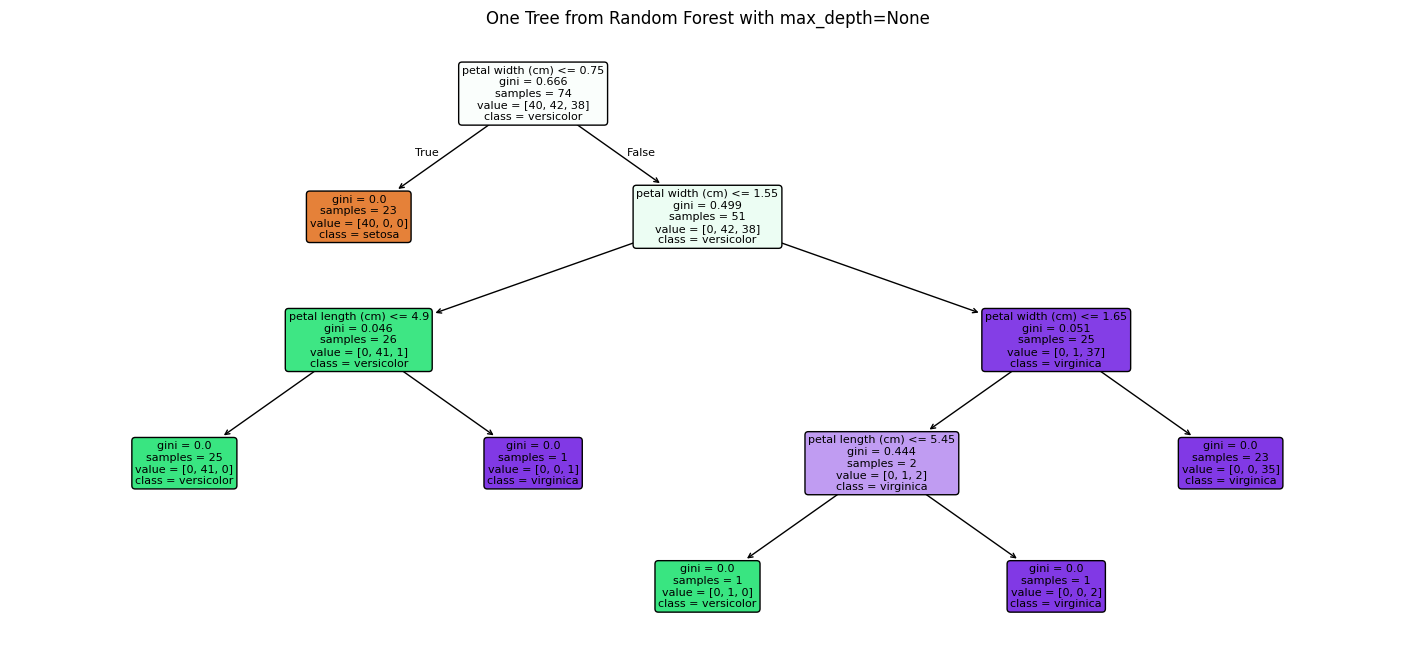

In [32]:
depth_values = [1, 2, 3, None]

for depth in depth_values:
    comparison_model = RandomForestClassifier(
        n_estimators=20,
        max_depth=depth,
        random_state=42
    )
    comparison_model.fit(X_train, y_train)

    plt.figure(figsize=(18, 8))
    plot_tree(
        comparison_model.estimators_[0],
        feature_names=X.columns,
        class_names=list(iris.target_names),
        filled=True,
        rounded=True,
        max_depth=4,
        fontsize=8
    )
    plt.title(
        f"One Tree from Random Forest with max_depth={depth}"
    )
    plt.show()

# Final summary

The complete process is:

```text
Training data
      |
Create a different bootstrap sample for every tree
      |
Consider random features at each split
      |
Train many Decision Trees
      |
Combine their class probabilities
      |
Final prediction
